# My Project is Movie Success Prediction using IMDb (top 1000 movies) Dataset by using metadata and plot overview.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb

In [2]:
df=pd.read_csv("/content/imdb_top_1000.csv")

df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [4]:
import numpy as np

df["Runtime"] = df["Runtime"].str.replace(" min", "").astype(float)
df["Gross"] = df["Gross"].str.replace(",", "")
df["Gross"] = pd.to_numeric(df["Gross"], errors="coerce")
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")
df["Released_Year"] = df["Released_Year"].fillna(df["Released_Year"].median())


In [5]:
df["Meta_score"] = df["Meta_score"].fillna(df["Meta_score"].median())
df["Gross"] = df["Gross"].fillna(df["Gross"].median())
df["Overview"] = df["Overview"].fillna("")

In [6]:
df.head(20)

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994.0,A,142.0,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972.0,A,175.0,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008.0,UA,152.0,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974.0,A,202.0,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957.0,U,96.0,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0
5,https://m.media-amazon.com/images/M/MV5BNzA5ZD...,The Lord of the Rings: The Return of the King,2003.0,U,201.0,"Action, Adventure, Drama",8.9,Gandalf and Aragorn lead the World of Men agai...,94.0,Peter Jackson,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom,1642758,377845905.0
6,https://m.media-amazon.com/images/M/MV5BNGNhMD...,Pulp Fiction,1994.0,A,154.0,"Crime, Drama",8.9,"The lives of two mob hitmen, a boxer, a gangst...",94.0,Quentin Tarantino,John Travolta,Uma Thurman,Samuel L. Jackson,Bruce Willis,1826188,107928762.0
7,https://m.media-amazon.com/images/M/MV5BNDE4OT...,Schindler's List,1993.0,A,195.0,"Biography, Drama, History",8.9,"In German-occupied Poland during World War II,...",94.0,Steven Spielberg,Liam Neeson,Ralph Fiennes,Ben Kingsley,Caroline Goodall,1213505,96898818.0
8,https://m.media-amazon.com/images/M/MV5BMjAxMz...,Inception,2010.0,UA,148.0,"Action, Adventure, Sci-Fi",8.8,A thief who steals corporate secrets through t...,74.0,Christopher Nolan,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page,Ken Watanabe,2067042,292576195.0
9,https://m.media-amazon.com/images/M/MV5BMmEzNT...,Fight Club,1999.0,A,139.0,Drama,8.8,An insomniac office worker and a devil-may-car...,66.0,David Fincher,Brad Pitt,Edward Norton,Meat Loaf,Zach Grenier,1854740,37030102.0


In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 100))

df["scaled_votes"] = scaler.fit_transform(df[["No_of_Votes"]])
df["scaled_gross"] = scaler.fit_transform(df[["Gross"]])
df["scaled_rating"] = df["IMDB_Rating"] * 10
df["scaled_meta"] = df["Meta_score"]
df.head(2)


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,scaled_votes,scaled_gross,scaled_rating,scaled_meta
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994.0,A,142.0,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0,100.000000,3.025659,93.0,80.0
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972.0,A,175.0,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,68.820701,14.409174,92.0,100.0


In [8]:
df["success_score"] = (
    0.4 * df["scaled_rating"] +
    0.30 * df["scaled_votes"] +
    0.15 * df["scaled_meta"] +
    0.15 * df["scaled_gross"]
)

df[["Series_Title","IMDB_Rating", "success_score"]].head()

,Series_Title,IMDB_Rating,success_score
0,The Shawshank Redemption,9.3,79.653849
1,The Godfather,9.2,74.607587
2,The Dark Knight,9.0,86.649277
3,The Godfather: Part II,9.0,64.716826
4,12 Angry Men,9.0,59.073132


In [9]:
X = df[["Released_Year", "Runtime", "Genre", "Certificate",
        "Director", "Star1", "Star2", "Star3", "Star4", "Overview"]]

y = df["success_score"]

In [10]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

In [11]:
numeric_features = ["Released_Year", "Runtime"]

categorical_features = ["Genre", "Certificate", "Director",
                        "Star1", "Star2", "Star3", "Star4"]

text_feature = "Overview"

text_transformer = Pipeline(steps=[
    ("extract", FunctionTransformer(lambda x: x.squeeze(), validate=False)),
    ("tfidf", TfidfVectorizer(max_features=300, stop_words="english"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("text", text_transformer, [text_feature])
    ]
)

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

RF = RandomForestRegressor(n_estimators=150, random_state=42)
LR = LinearRegression()

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
RF_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RF)
])

LR_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LR)
])


In [15]:
df.dtypes

,0
Poster_Link,object
Series_Title,object
Released_Year,float64
Certificate,object
Runtime,float64
Genre,object
IMDB_Rating,float64
Overview,object
Meta_score,float64
Director,object


In [16]:

RF_pipeline.fit(X_train, y_train)
LR_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['Released_Year', 'Runtime']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Genre', 'Certificate',
                                                   'Director', 'Star1', 'Star2',
                                                   'Star3', 'Star4']),
                                                 ('text',
                                                  Pipeline(steps=[('extract',
                                                                   FunctionTransformer(func=<function <lambda> at 0x78eaee17d300>)),
                                                                  ('tfidf',
                                                                   TfidfVectorizer(max_features=300,
                                                                                   stop_words='english'))]),
                                                  ['Overview'])])),
                ('model', LinearRegression())])

In [17]:
from sklearn.metrics import mean_absolute_error, r2_score

RF_preds = RF_pipeline.predict(X_test)
LR_preds = LR_pipeline.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, RF_preds))
print("Random Forest R2:", r2_score(y_test, RF_preds))

print("Linear Regression MAE:", mean_absolute_error(y_test, LR_preds))
print("Linear Regression R2:", r2_score(y_test, LR_preds))

Random Forest MAE: 3.2290293617801806
Random Forest R2: 0.30452145052913626
Linear Regression MAE: 3.575934166575443
Linear Regression R2: 0.3166335255071754


# Scatter graph
The below scatter plot shows the relationship between the actual movie success scores and the predicted scores generated by the Random Forest model.
Each point represents one movie.
Points closer to the diagonal indicate more accurate predictions.








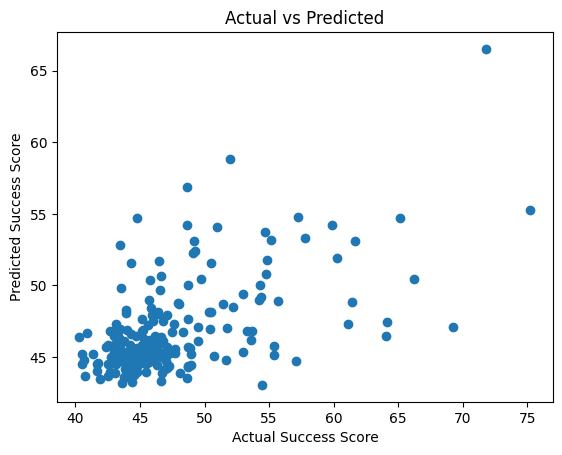

In [30]:
import matplotlib.pyplot as plt

plt.scatter(y_test, RF_preds)
plt.xlabel("Actual Success Score")
plt.ylabel("Predicted Success Score")
plt.title("Actual vs Predicted")
plt.show()

#Line Graph
The below line graph shows how close my model's predictions are to the real values.



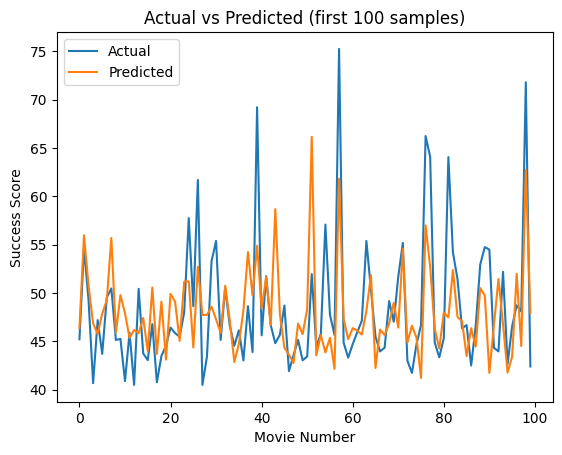

In [29]:
plt.plot(y_test.values[:100], label="Actual")
plt.plot( LR_preds[:100], label="Predicted")
plt.xlabel("Movie Number")
plt.ylabel("Success Score")
plt.legend()
plt.title("Actual vs Predicted (first 100 samples)")
plt.show()